# Máquinas Térmicas - Lección 3
## Ciclos Biogeoquímicos
*La geología de los combustibles fósiles se trata en la Lección 4.*

**Autor:** Camilo Bayona  
**Fecha:** 23/07/2025




### Objetivos de aprendizaje  

1. Describir los procesos y reservorios principales de los ciclos del **agua, carbono y nitrógeno**, entre otros.  
2. Relacionar el ciclo del carbono con la formación de **combustibles fósiles** (desarrollado en la Lección 4).  
3. Aplicar balances de masa sencillos para cuantificar flujos y tiempos de residencia.  
4. Cuantificar reservorios y flujos mediante **tiempos de residencia** $\tau=M/F$.  
5. Preparar el terreno para la lección siguiente sobre **combustibles convencionales y su combustión**.


## 1. Introducción

Los ciclos biogeoquímicos describen la circulación de la materia a través de la **biosfera, atmósfera, hidrósfera y litosfera**.  
Estos ciclos regulan la disponibilidad de nutrientes para los seres vivos y determinan cómo se transfiere la energía entre organismos y su entorno.

Para los ingenieros mecánicos, entender estos ciclos es esencial porque explican el origen de los **combustibles fósiles** (carbón, petróleo y gas natural), que se formaron a partir de materia orgánica sometida a procesos geológicos de largo plazo:
* **Suministro de energía:** los hidrocarburos que usamos como combustible son el resultado de millones de años de evolución dentro del ciclo del carbono y del agua.  
* **Impacto ambiental:** las emisiones de CO₂, H₂O y NOₓ generadas en procesos térmicos vuelven a dichos ciclos y alteran su equilibrio.

Este cuaderno explora los principales ciclos biogeoquímicos (agua, carbono, nitrógeno, azufre y fósforo) y explica cómo la dinámica de la materia en la Tierra está relacionada con la formación geológica del carbón y los hidrocarburos (petróleo y gas natural).

In [2]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "networkx", "matplotlib", "pandas"], check=True)


In [3]:
# === Setup: librerías, paleta y maquinaria reutilizable de ciclos ============
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

SEG_ANO = 365.25 * 24 * 3600
COL_CICLO = {"Agua": "#2E86C1", "Carbono": "#27AE60", "Nitrógeno": "#E1A100",
             "Azufre": "#CA6F1E", "Fósforo": "#8E44AD"}

# --------------------------------------------------------------------------
# Datos didácticos de los cinco ciclos. Cada arco lleva tres "capas" de rótulo:
#   proceso (nombre), masa (flujo), energía (asociada) y tiempo (escala).
# Los reservorios (nodos) llevan una masa para escalar su tamaño en el diagrama.
# Valores de orden de magnitud tomados de la literatura (didácticos).
# --------------------------------------------------------------------------
CICLOS = {
 "Agua": {
   "unidad_masa": "10¹² kg/año", "unidad_res": "10¹⁵ kg",
   "nodos": {"Océanos": (0, -1, 1.37e6), "Atmósfera": (0, 2, 13),
             "Nubes": (1.4, 2.6, 13), "Superficie": (1.4, -0.3, 120),
             "Acuíferos": (2.8, -1, 23400)},
   "arcos": [("Océanos","Atmósfera","evaporación",434,"absorbe calor (Lv)","≈9 días (atm)"),
             ("Atmósfera","Nubes","condensación",434,"libera calor (Lv)","horas"),
             ("Nubes","Superficie","precipitación",111,"energía potencial","días"),
             ("Superficie","Océanos","escorrentía",111,"energía potencial","semanas"),
             ("Superficie","Acuíferos","infiltración",30,"≈0","años"),
             ("Acuíferos","Océanos","retorno lento",0.3,"≈0","≈3000 años")]},
 "Carbono": {
   "unidad_masa": "Gt C/año", "unidad_res": "Gt C",
   "nodos": {"Atmósfera": (0, 2, 880), "Plantas": (-1.6, 1, 560),
             "Animales": (1.6, 1, 2), "Suelo": (0, 0, 1600),
             "Océanos": (2, -0.6, 38000), "Rocas": (-2, -0.6, 4_000_000),
             "Combustibles\nfósiles": (0, -1.6, 4000)},
   "arcos": [("Atmósfera","Plantas","fotosíntesis",120,"almacena energía solar","estacional"),
             ("Plantas","Animales","alimentación",10,"transf. trófica","años"),
             ("Animales","Atmósfera","respiración",10,"libera energía","días–años"),
             ("Plantas","Atmósfera","respiración",60,"libera energía","estacional"),
             ("Plantas","Suelo","restos",50,"—","años"),
             ("Suelo","Atmósfera","descomposición",50,"libera energía","años–siglos"),
             ("Atmósfera","Océanos","disolución",70,"—","≈1 año"),
             ("Océanos","Atmósfera","liberación",70,"—","≈1 año"),
             ("Suelo","Combustibles\nfósiles","enterramiento",0.2,"—","10⁶–10⁸ años"),
             ("Combustibles\nfósiles","Atmósfera","combustión",11,"libera energía","≈1 siglo"),
             ("Rocas","Atmósfera","vulcanismo",0.1,"—","10⁶ años")]},
 "Nitrógeno": {
   "unidad_masa": "Tg N/año", "unidad_res": "Tg N",
   "nodos": {"Atmósfera\n(N₂)": (0, 2, 3.9e9), "Bacterias\nfijadoras": (-1.3, 1, 1),
             "Suelo (NH₃)": (-1.3, 0, 1e5), "Nitrosomonas": (0, 0, 1),
             "Nitrobacter": (1.3, 0, 1), "Plantas": (1.3, 1.2, 1e4),
             "Animales": (2.6, 1.2, 200), "Bacterias\ndesnitrif.": (1.3, -1.2, 1)},
   "arcos": [("Atmósfera\n(N₂)","Bacterias\nfijadoras","fijación",140,"rompe N≡N (946 kJ/mol)","—"),
             ("Bacterias\nfijadoras","Suelo (NH₃)","amonificación",140,"—","—"),
             ("Suelo (NH₃)","Nitrosomonas","nitrificación",120,"quimiosíntesis","—"),
             ("Nitrosomonas","Nitrobacter","NO₂⁻→NO₃⁻",120,"quimiosíntesis","—"),
             ("Nitrobacter","Plantas","asimilación",100,"—","estacional"),
             ("Plantas","Animales","alimentación",20,"transf. trófica","años"),
             ("Animales","Suelo (NH₃)","descomposición",120,"—","meses"),
             ("Nitrobacter","Bacterias\ndesnitrif.","desnitrificación",110,"—","—"),
             ("Bacterias\ndesnitrif.","Atmósfera\n(N₂)","liberación N₂",110,"—","—")]},
 "Azufre": {
   "unidad_masa": "Tg S/año", "unidad_res": "Tg S",
   "nodos": {"Suelo/Agua": (0, 0, 3e8), "Plantas": (-1.3, 1, 100),
             "Animales": (1.3, 1, 20), "Descompon.": (1.3, -0.6, 5),
             "Océano": (-1.3, -0.6, 1.3e9), "Atmósfera": (0, 2, 5)},
   "arcos": [("Suelo/Agua","Plantas","asimilación SO₄²⁻",80,"—","estacional"),
             ("Plantas","Animales","alimentación",20,"—","años"),
             ("Animales","Descompon.","descomposición",100,"—","meses"),
             ("Descompon.","Suelo/Agua","sulfato / H₂S",100,"—","meses"),
             ("Suelo/Agua","Océano","transporte fluvial",130,"—","años"),
             ("Océano","Atmósfera","H₂S / SO₂ (DMS)",40,"—","días"),
             ("Atmósfera","Suelo/Agua","lluvia ácida",40,"forma H₂SO₄","días")]},
 "Fósforo": {
   "unidad_masa": "Tg P/año", "unidad_res": "Tg P",
   "nodos": {"Rocas/\nFosfatos": (-2, 0, 4e9), "Suelo": (0, 0, 2e5),
             "Plantas": (0, 1.2, 3000), "Animales": (2, 1.2, 500),
             "Descompon.": (2, -0.5, 100), "Agua Dulce": (0, -1.2, 90),
             "Océano": (-2, -1.2, 1e5), "Sedimentos\nMarinos": (-4, -1.2, 4e9)},
   "arcos": [("Rocas/\nFosfatos","Suelo","meteorización",14,"—","10³–10⁶ años"),
             ("Suelo","Plantas","absorción PO₄³⁻",60,"—","estacional"),
             ("Plantas","Animales","alimentación",30,"—","años"),
             ("Animales","Descompon.","excretas y restos",60,"—","meses"),
             ("Descompon.","Suelo","mineralización",60,"—","meses"),
             ("Suelo","Agua Dulce","escorrentía",8,"—","años"),
             ("Agua Dulce","Océano","transporte fluvial",8,"—","años"),
             ("Océano","Sedimentos\nMarinos","sedimentación",8,"—","10³ años"),
             ("Sedimentos\nMarinos","Rocas/\nFosfatos","levantamiento",8,"—","10⁷ años")]},
}

def draw_cycle(nombre, capa="proceso"):
    """Dibuja un ciclo con capa de rótulos conmutable (proceso/masa/energía/tiempo).
    El tamaño de cada nodo es proporcional (log) a la masa del reservorio."""
    d = CICLOS[nombre]; col = COL_CICLO[nombre]
    G = nx.DiGraph()
    pos, masas = {}, {}
    for n, (x, y, m) in d["nodos"].items():
        G.add_node(n); pos[n] = (x, y); masas[n] = m
    idx = {"proceso": 0, "masa": 1, "energía": 2, "tiempo": 3}[capa]
    labels = {}
    for u, v, proc, mflux, ener, t in d["arcos"]:
        G.add_edge(u, v)
        labels[(u, v)] = [proc, f"{mflux:g}", ener, t][idx]
    mmin = min(masas.values())
    sizes = [500 + 1400 * np.log10(masas[n] / mmin + 1) / np.log10(max(masas.values()) / mmin + 1)
             for n in G.nodes()]
    fig, ax = plt.subplots(figsize=(9, 5.6))
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=col, alpha=0.35,
                           edgecolors=col, linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, ax=ax, node_size=sizes, arrows=True, arrowsize=13,
                           edge_color="#555555", width=1.3,
                           connectionstyle="arc3,rad=0.08")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8,
                                 bbox=dict(boxstyle="round,pad=0.15", fc="white",
                                           ec="none", alpha=0.7), ax=ax)
    titulo_capa = {"proceso": "procesos", "masa": f"flujo de masa [{d['unidad_masa']}]",
                   "energía": "energía asociada", "tiempo": "escala temporal"}[capa]
    ax.set_title(f"Ciclo del {nombre.lower()} — capa: {titulo_capa}\n"
                 f"(tamaño de nodo ∝ masa del reservorio, en {d['unidad_res']})",
                 fontsize=11)
    ax.axis("off"); plt.tight_layout(); plt.show()

def widget_ciclo(nombre):
    interact(lambda capa: draw_cycle(nombre, capa),
             capa=Dropdown(options=["proceso", "masa", "energía", "tiempo"],
                           value="proceso", description="capa"))

def tiempo_residencia(nombre):
    """Tabla de tiempo de residencia τ = M / F_salida por reservorio [años]."""
    d = CICLOS[nombre]
    out = {}
    for u, v, proc, mflux, ener, t in d["arcos"]:
        out[u] = out.get(u, 0) + mflux
    filas = []
    for n, (x, y, m) in d["nodos"].items():
        F = out.get(n, np.nan)
        tau = m / F if F and not np.isnan(F) else np.nan
        filas.append((n.replace("\n", " "), m, F, tau))
    return pd.DataFrame(filas, columns=[f"Reservorio", f"Masa [{d['unidad_res']}]",
                                        f"F_salida [{d['unidad_masa']}]", "τ = M/F"])

print("Setup OK — 5 ciclos cargados:", ", ".join(CICLOS))


Setup OK — 5 ciclos cargados: Agua, Carbono, Nitrógeno, Azufre, Fósforo


,Esfera,Descripción (muy breve),Masa aprox.,Función en ciclos BGQ
0,Litosfera,Corteza + parte superior del manto (~0-100 km),≈ 4 × 10²⁴ kg,"Fuente y sumidero de C, N, S a muy largo plazo"
1,Hidrósfera,"Aguas oceánicas, continentales y subterráneas",≈ 1.4 × 10²¹ kg,"Intercambio rápido H₂O, C y calor (clima)"
2,Biosfera,Conjunto de seres vivos y materia orgánica activa,≈ 1 × 10¹⁵ kg,"Fija C y N, libera O₂, regula flujos energéticos"
3,Atmósfera,"Capa gaseosa (troposfera-estratosfera, etc.)",≈ 5 × 10¹⁸ kg,Almacén y transporte de gases reactivos y vapor


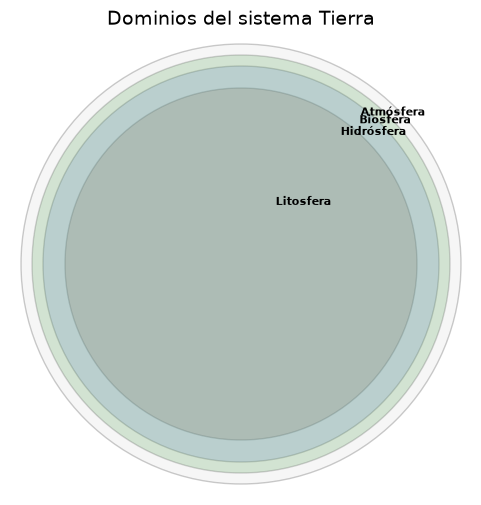

In [4]:
# Esferas del sistema Tierra: diagrama y datos básicos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# 1. Datos resumidos
# ---------------------------
datos = pd.DataFrame({
    "Esfera":      ["Litosfera", "Hidrósfera", "Biosfera", "Atmósfera"],
    "Descripción (muy breve)": [
        "Corteza + parte superior del manto (~0-100 km)",
        "Aguas oceánicas, continentales y subterráneas",
        "Conjunto de seres vivos y materia orgánica activa",
        "Capa gaseosa (troposfera-estratosfera, etc.)"
    ],
    "Masa aprox.": ["≈ 4 × 10²⁴ kg", "≈ 1.4 × 10²¹ kg", "≈ 1 × 10¹⁵ kg", "≈ 5 × 10¹⁸ kg"],
    "Función en ciclos BGQ": [
        "Fuente y sumidero de C, N, S a muy largo plazo",
        "Intercambio rápido H₂O, C y calor (clima)",
        "Fija C y N, libera O₂, regula flujos energéticos",
        "Almacén y transporte de gases reactivos y vapor"
    ]
})

# Mostrar tabla (en Jupyter aparece como HTML interactivo)
display(datos)

# ---------------------------
# 2. Diagrama concéntrico
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

# Definición de capas: (nombre, radio exterior, color)
capas = [
    ("Litosfera", 0.80, "saddlebrown"),
    ("Hidrósfera", 0.90, "royalblue"),
    ("Biosfera", 0.95, "forestgreen"),
    ("Atmósfera", 1.00, "lightgray")
]

radio_prev = 0.0
for nombre, radio_ext, color in capas:
    # Dibujar anillo
    ring = plt.Circle((0, 0), radio_ext, color=color, alpha=0.2,
                      ec='k', lw=1.0)
    ax.add_patch(ring)
    # Etiqueta ligeramente dentro del anillo
    angle = 45                           # grados
    r_text = (radio_prev + radio_ext) / 2
    x, y = r_text * np.cos(np.deg2rad(angle)), r_text * np.sin(np.deg2rad(angle))
    ax.text(x, y, nombre, ha='center', va='center', fontsize=8, weight='bold')
    radio_prev = radio_ext

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.axis('off')
plt.title("Dominios del sistema Tierra", fontsize=14)
plt.show()

## 2. Cosmología de los elementos químicos
Antes de circular por la Tierra, los átomos de $\mathrm{C}$, $\mathrm{N}$, $\mathrm{O}$, $\mathrm{S}$ y $\mathrm{P}$ tuvieron que **fabricarse**. El Big Bang solo produjo hidrógeno y helio (y trazas de litio); **todo elemento más pesado nació dentro de estrellas**.

**El carbono, base de la vida y de los combustibles fósiles**, se forja en el núcleo de estrellas gigantes rojas por el **proceso triple-alfa**, la fusión de tres núcleos de helio:

$$3\,{}^{4}\mathrm{He} \;\longrightarrow\; {}^{12}\mathrm{C} + \gamma, \qquad Q = +7.275\ \mathrm{MeV}.$$

Las estrellas más masivas encadenan fusiones sucesivas ($\mathrm{He}\to\mathrm{C}\to\mathrm{O}\to\mathrm{Ne}\to\mathrm{Si}\to\mathrm{Fe}$) formando una estructura en **capas de cebolla**. La fusión se detiene en el **hierro-56**, el núcleo de mayor energía de enlace por nucleón: fusionar más allá **consume** energía en vez de liberarla, y el núcleo colapsa en una **supernova** que siembra el medio interestelar con los elementos pesados. El nitrógeno y el oxígeno se producen además en el **ciclo CNO**, que usa C, N y O como catalizadores para fusionar hidrógeno:

$$4\,{}^{1}\mathrm{H} \;\longrightarrow\; {}^{4}\mathrm{He} + 2e^{+} + 2\nu_e, \qquad Q \approx 26.7\ \mathrm{MeV}.$$


In [5]:
# WIDGET 1 — nucleosíntesis por masa estelar: ¿hasta qué elemento llega la fusión?
# Estructura en capas de cebolla y temperatura de núcleo según la masa de la estrella.
ETAPAS = [  # (elemento que se fusiona, producto, T_encendido [K], símbolo)
    ("H", "He", 1.5e7, "H→He"), ("He", "C, O", 1.0e8, "He→C (triple-α)"),
    ("C", "Ne, Na, Mg", 8e8, "C→Ne"), ("Ne", "O, Mg", 1.5e9, "Ne→O"),
    ("O", "Si, S", 2.0e9, "O→Si"), ("Si", "Fe, Ni", 3.0e9, "Si→Fe (fin)")]

def nucleosintesis(M_estelar=1.0):
    # nº de etapas alcanzables según la masa (Msun) — umbrales didácticos
    if M_estelar < 0.5:      n = 1; destino = "enana blanca de He (no llega al C)"
    elif M_estelar < 2:      n = 2; destino = "enana blanca de C-O"
    elif M_estelar < 8:      n = 2; destino = "gigante roja → enana blanca de C-O (siembra C, N por viento)"
    elif M_estelar < 11:     n = 4; destino = "supernova (núcleo O-Ne-Mg)"
    else:                    n = 6; destino = "supernova de colapso de núcleo (núcleo de Fe)"
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5), gridspec_kw={"width_ratios": [1, 1.2]})
    # panel izquierdo: capas de cebolla
    colores = ["#FDE68A", "#FCA5A5", "#C4B5FD", "#93C5FD", "#6EE7B7", "#9CA3AF"]
    for i in range(n):
        r = 1.0 - i * (0.9 / n)
        ax1.add_patch(plt.Circle((0, 0), r, color=colores[i], ec="k", lw=1, zorder=i))
        elem = ETAPAS[i][1].split(",")[0]
        ax1.text(0, r - (0.9 / n) / 2, elem, ha="center", va="center",
                 fontsize=10, fontweight="bold", zorder=n + 1)
    if n >= 2:
        ax1.scatter([0], [0], s=1)  # marca núcleo
    ax1.text(0, -1.18, "triple-α (C) " + ("✓ activo" if n >= 2 else "✗ no alcanzado"),
             ha="center", fontsize=9, color="#B91C1C" if n >= 2 else "#6B7280")
    ax1.set_xlim(-1.1, 1.1); ax1.set_ylim(-1.3, 1.1); ax1.set_aspect("equal"); ax1.axis("off")
    ax1.set_title(f"Estructura en capas ({M_estelar:.1f} $M_\\odot$)")
    # panel derecho: temperatura de encendido por etapa
    ys = np.arange(len(ETAPAS))
    ax2.barh(ys, [e[2] for e in ETAPAS],
             color=[colores[i] if i < n else "#E5E7EB" for i in range(len(ETAPAS))],
             edgecolor="k")
    ax2.set_yticks(ys); ax2.set_yticklabels([e[3] for e in ETAPAS])
    ax2.set_xscale("log"); ax2.invert_yaxis()
    ax2.set_xlabel("Temperatura de encendido del núcleo [K]")
    ax2.axvline(3.0e9, ls="--", color="#B91C1C", lw=1)
    ax2.text(3.0e9, len(ETAPAS) - 0.4, " pico Fe-56\n (fin de la fusión)", fontsize=8, color="#B91C1C")
    for i in range(len(ETAPAS)):
        ax2.text(ETAPAS[i][2], i, "  ✓" if i < n else "  ✗", va="center",
                 fontsize=9, color="green" if i < n else "#9CA3AF")
    ax2.set_title("Cadena de fusión alcanzada")
    fig.suptitle(f"Destino: {destino}", fontsize=11)
    plt.tight_layout(); plt.show()

interact(nucleosintesis,
         M_estelar=FloatSlider(1.0, min=0.3, max=25.0, step=0.1, description="M [M_☉]"));


interactive(children=(FloatSlider(value=1.0, description='M [M_☉]', max=25.0, min=0.3), Output()), _dom_classe…

In [ ]:
# WIDGET 2 — tabla periódica coloreada por sitio de nucleosíntesis (versión simplificada
# de la carta de origen de los elementos de J. Johnson / NASA). Resalta C, N, O, S, P, Fe.
PT_ROWS = [
 ["H",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"He"],
 ["Li","Be",None,None,None,None,None,None,None,None,None,None,"B","C","N","O","F","Ne"],
 ["Na","Mg",None,None,None,None,None,None,None,None,None,None,"Al","Si","P","S","Cl","Ar"],
 ["K","Ca","Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn","Ga","Ge","As","Se","Br","Kr"],
 ["Rb","Sr","Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd","In","Sn","Sb","Te","I","Xe"],
 ["Cs","Ba","La","Hf","Ta","W","Re","Os","Ir","Pt","Au","Hg","Tl","Pb","Bi","Po","At","Rn"],
 ["Fr","Ra","Ac","Rf","Db","Sg","Bh","Hs","Mt","Ds","Rg","Cn","Nh","Fl","Mc","Lv","Ts","Og"]]
PT_F = [["Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu"],
        ["Th","Pa","U","Np","Pu","Am","Cm","Bk","Cf","Es","Fm","Md","No","Lr"]]
ORIGEN = {  # categoría -> color
 "Big Bang": "#7FB3D5", "Rayos cósmicos": "#F1948A", "Estrellas moribundas (AGB)": "#82E0AA",
 "Estrellas masivas": "#F8C471", "Supernovas (Ia)": "#C39BD3",
 "Fusión de estrellas de neutrones": "#F0B27A", "Artificial": "#D5D8DC"}
# asignación (simplificada y didáctica) de elementos clave a categorías
CAT = {}
for e in ["H","He"]: CAT[e] = "Big Bang"
for e in ["Li","Be","B"]: CAT[e] = "Rayos cósmicos"
for e in ["C","N","F","Na"]: CAT[e] = "Estrellas moribundas (AGB)"
for e in ["O","Ne","Mg","Al","Si","P","S","Cl","Ar","K","Ca","Sc","Ti","V","Cu","Zn"]:
    CAT[e] = "Estrellas masivas"
for e in ["Cr","Mn","Fe","Co","Ni"]: CAT[e] = "Supernovas (Ia)"
for e in ["Ga","Ge","As","Se","Br","Kr","Rb","Sr","Y","Zr","Nb","Mo","Ru","Rh","Pd","Ag","Cd",
          "In","Sn","Sb","Te","I","Xe","Cs","Ba","La","Hf","Ta","W","Re","Os","Ir","Pt","Au",
          "Hg","Tl","Pb","Bi","Ce","Pr","Nd","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Th","U"]:
    CAT[e] = "Fusión de estrellas de neutrones"
DESTACAR = {"C", "N", "O", "S", "P", "Fe"}
# época (Ga desde el Big Bang) en que cada fuente empieza a aportar
ACTIVA_DESDE = {"Big Bang": 0.0, "Rayos cósmicos": 0.2, "Estrellas masivas": 0.2,
                "Supernovas (Ia)": 1.0, "Estrellas moribundas (AGB)": 1.0,
                "Fusión de estrellas de neutrones": 0.3, "Artificial": 13.7}

def _celda(ax, x, y, sym, t):
    cat = CAT.get(sym, "Artificial")
    activo = t >= ACTIVA_DESDE[cat]
    color = ORIGEN[cat] if activo else "#F4F6F7"
    ax.add_patch(mpatches.Rectangle((x, y), 0.92, 0.92, facecolor=color,
                 edgecolor="#B91C1C" if sym in DESTACAR else "#909497",
                 lw=2.2 if sym in DESTACAR else 0.6, zorder=2))
    ax.text(x + 0.46, y + 0.46, sym, ha="center", va="center", zorder=3,
            fontsize=7.5, fontweight="bold" if sym in DESTACAR else "normal",
            color="black" if activo else "#BDC3C7")

def tabla_periodica(epoca_Ga=13.8):
    fig, ax = plt.subplots(figsize=(12, 7.5))
    for r, row in enumerate(PT_ROWS):
        for c, sym in enumerate(row):
            if sym: _celda(ax, c, -r, sym, epoca_Ga)
    for r, row in enumerate(PT_F):        # bloque f, desplazado abajo
        for c, sym in enumerate(row):
            _celda(ax, c + 2, -(r + 8.2), sym, epoca_Ga)
    handles = [mpatches.Patch(color=ORIGEN[k], label=k) for k in ORIGEN]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=4, fontsize=8, frameon=False)
    ax.text(9, 0.6, f"época cósmica ≈ {epoca_Ga:.1f} Ga", fontsize=11, ha="center",
            bbox=dict(boxstyle="round", fc="#FEF9E7", ec="#909497"))
    ax.text(9, -6.6, "borde rojo: elementos de esta lección (C, N, O, S, P) y el Fe",
            fontsize=8.5, ha="center", color="#B91C1C")
    ax.set_xlim(-0.4, 18.4); ax.set_ylim(-11.5, 1.4); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title("Origen cósmico de los elementos (versión simplificada de la carta de J. Johnson)",
                 fontsize=12)
    plt.tight_layout(); plt.show()

interact(tabla_periodica,
         epoca_Ga=FloatSlider(13.8, min=0.0, max=13.8, step=0.1, description="época [Ga]"));


interactive(children=(FloatSlider(value=13.8, description='época [Ga]', max=13.8), Output()), _dom_classes=('w…

## 3. Concentraciones atmosféricas a lo largo de las eras geológicas
La composición del aire no ha sido constante: el $\mathrm{O_2}$ apareció con la fotosíntesis (**Gran Oxidación**, hace ≈2.4 Ga), alcanzó un máximo de ~35 % en el **Carbonífero** (bosques que originaron el carbón, hace ≈300 Ma) y el $\mathrm{CO_2}$ ha caído en varios órdenes de magnitud a medida que el carbono se enterraba en la litosfera. El widget siguiente reconstruye esa evolución.


In [ ]:
# WIDGET 3 — evolución de CO₂, O₂ y N₂ atmosféricos en el tiempo geológico
# Datos didácticos (órdenes de magnitud) reconstruidos de proxies geoquímicos.
T_GA = np.array([4.4, 4.0, 3.5, 3.0, 2.5, 2.4, 2.0, 1.5, 1.0, 0.54, 0.36, 0.30, 0.25, 0.05, 0.0])
CO2 = np.array([  80,  70,  30,  20,  10,   8,   2, 0.6, 0.3, 0.20,0.10,0.03,0.10,0.03,0.042])  # % vol
O2  = np.array([1e-6,1e-6,1e-5,1e-4,1e-3, 0.5,   2,   4,   6,  15,  25,  35,  23,  21,  21.0])   # % vol
N2  = np.array([  90,  85,  80,  79,  80,  78,  78,  78,  78,  78,  74,  63,  76,  78,  78.1])   # % vol
EVENTOS = {"Gran Oxidación": 2.4, "Explosión Cámbrica": 0.54, "Pico O₂ Carbonífero": 0.30,
           "Extinción P-T": 0.25, "Presente": 0.0}

def atmosfera(evento="Pico O₂ Carbonífero", escala_CO2_log=True):
    t0 = EVENTOS[evento]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(T_GA, O2, "-o", color="#2E86C1", lw=2, ms=4, label="O₂ [% vol]")
    ax.plot(T_GA, N2, "-o", color="#7D3C98", lw=2, ms=4, label="N₂ [% vol]")
    ax.plot(T_GA, CO2, "-o", color="#27AE60", lw=2, ms=4, label="CO₂ [% vol]")
    if escala_CO2_log: ax.set_yscale("log"); ax.set_ylim(1e-3, 200)
    else: ax.set_ylim(0, 100)
    ax.invert_xaxis()
    ax.axvline(t0, ls="--", color="#B91C1C", lw=1.4)
    ax.text(t0, ax.get_ylim()[1], f" {evento}", color="#B91C1C", fontsize=9,
            va="top", ha="left" if t0 > 0.2 else "right")
    # lecturas interpoladas en el evento
    for serie, nom, col in ((O2, "O₂", "#2E86C1"), (N2, "N₂", "#7D3C98"), (CO2, "CO₂", "#27AE60")):
        val = np.interp(t0, T_GA[::-1], serie[::-1])
        ax.scatter([t0], [val], color=col, s=60, zorder=5, edgecolors="k")
    ax.set_xlabel("Miles de millones de años antes del presente [Ga]")
    ax.set_ylabel("Fracción en volumen [%]" + ("  (escala log)" if escala_CO2_log else ""))
    ax.set_title("Composición de la atmósfera terrestre en el tiempo geológico")
    ax.legend(loc="center left"); ax.grid(alpha=0.3, which="both")
    plt.tight_layout(); plt.show()
    o2v = np.interp(t0, T_GA[::-1], O2[::-1]); co2v = np.interp(t0, T_GA[::-1], CO2[::-1])
    print(f"En «{evento}» (hace {t0:.2f} Ga):  O₂ ≈ {o2v:.2g} %  ·  CO₂ ≈ {co2v:.2g} %  "
          f"(hoy: O₂ 21 %, CO₂ 0.042 %)")

interact(atmosfera,
         evento=Dropdown(options=list(EVENTOS), value="Pico O₂ Carbonífero", description="evento"),
         escala_CO2_log=Dropdown(options=[("log", True), ("lineal", False)], value=True,
                                 description="escala Y"));


interactive(children=(Dropdown(description='evento', index=2, options=('Gran Oxidación', 'Explosión Cámbrica',…

## 4. Ciclo del agua (ciclo hidrológico)

## Ciclo del agua (ciclo hidrológico)


El agua circula continuamente entre la atmósfera, la superficie y el subsuelo mediante procesos de **evaporación**, **condensación**, **precipitación** e **infiltración**. La precipitación que cae sobre la superficie se divide entre el flujo superficial (que alimenta ríos, lagos y humedales) y la infiltración en el suelo. Parte del agua infiltrada recarga los **acuíferos** y se mueve lentamente hacia cuerpos de agua superficiales; otra parte vuelve a la atmósfera por **evaporación**. Este ciclo regula la disponibilidad de agua dulce y controla procesos de erosión, transporte de sedimentos y formación de rocas sedimentarias.

La energía necesaria para evaporar el agua es grande; por ejemplo, evaporar 1 kilogramo de agua requiere aproximadamente 2,26 × 10⁶ J (calor de vaporización). Esta energía latente es importante en fenómenos meteorológicos y en el diseño de intercambiadores de calor.

**Calor latente de vaporización** (energía para evaporar el agua):

$$Q = m\,L_v, \qquad L_v \approx 2.26\times10^{6}\ \mathrm{J/kg}.$$

**Tiempo de residencia** de un reservorio (masa $M$, flujo de salida $F$):

$$\tau = \frac{M}{F}.$$


* **Reservorios:** océanos (~97 %), hielo continental, aguas subterráneas, atmósfera, biosfera.  
* **Flujos clave:** evaporación, condensación, precipitación, escorrentía, infiltración.  
* **Tiempo de residencia promedio:**  
  * Atmósfera ≈ 9 días  
  * Océanos ≈ 3 000 años

> _Notación_: \( F_{ij} \) = flujo del reservorio _i_ al _j_ [kg · a⁻¹];  
> \( M_i \) = masa en el reservorio _i_ [kg].

El diagrama interactivo y la tabla de tiempos de residencia se generan a continuación.

In [ ]:
# WIDGET — ciclo del agua con capas conmutables (proceso / masa / energía / tiempo)
widget_ciclo("Agua")

interactive(children=(Dropdown(description='capa', options=('proceso', 'masa', 'energía', 'tiempo'), value='pr…

In [9]:
# Tiempo de residencia τ = M/F por reservorio (reemplaza el balance simplificado anterior)
display(tiempo_residencia("Agua").round(2))
print("Verificación: τ(Atmósfera) ≈ %.0f días — compárese con el valor de referencia ≈ 9 días"
      % (tiempo_residencia("Agua").set_index("Reservorio").loc["Atmósfera", "τ = M/F"] * 365.25))

,Reservorio,Masa [10¹⁵ kg],F_salida [10¹² kg/año],τ = M/F
0,Océanos,1370000.0,434.0,3156.68
1,Atmósfera,13.0,434.0,0.03
2,Nubes,13.0,111.0,0.12
3,Superficie,120.0,141.0,0.85
4,Acuíferos,23400.0,0.3,78000.00


Verificación: τ(Atmósfera) ≈ 11 días — compárese con el valor de referencia ≈ 9 días


## 5. Ciclo del carbono

## Ciclo del carbono

El carbono es un elemento esencial para la vida y circula entre la atmósfera, la biosfera, la hidrósfera y la litosfera. Los **productores** toman dióxido de carbono (CO₂) del aire o bicarbonato disuelto para realizar la **fotosíntesis**, produciendo compuestos orgánicos como la glucosa. Los **consumidores** obtienen el carbono al alimentarse de plantas y otros animales. Durante la **respiración**, los organismos descomponen compuestos orgánicos y liberan CO₂ a la atmósfera. Los restos de organismos y desechos se descomponen por acción de hongos y bacterias, liberando CO₂. El carbono también se almacena en rocas carbonatadas y en los océanos, y es liberado por **erupciones volcánicas**. En las capas profundas de la corteza, la acumulación de restos orgánicos dio origen a los **combustibles fósiles** (petróleo, gas natural y carbón). El uso intensivo de estos combustibles devuelve rápidamente a la atmósfera el carbono que estuvo almacenado durante millones de años.

En el ciclo geológico del carbono, la meteorización de las rocas libera carbono a los océanos, donde precipita como carbonatos y finalmente se convierte en piedra caliza; la subducción y el vulcanismo vuelven a liberar el carbono a la atmósfera.

**Fotosíntesis** (captura de carbono y energía solar) y su inversa, la **respiración/combustión**:

$$6\,\mathrm{CO_2} + 6\,\mathrm{H_2O} \;\xrightarrow{\text{luz}}\; \mathrm{C_6H_{12}O_6} + 6\,\mathrm{O_2}.$$


| Reservorio          | Masa (Gt C) | Flujo principal (Gt C a⁻¹)                   |
| ------------------- | ----------- | -------------------------------------------- |
| Atmósfera           | 880         | Fotosíntesis (−120) / Combustión fósil (+11) |
| Biosfera            | 560         | Respiración (+119)                           |
| Océano superficial  | 900         | Intercambio aire-mar (±70)                   |
| Sedimentos/petróleo | 4 000 000   | Enterramiento (0.2)                          |


In [10]:
# WIDGET — ciclo del carbono con capas conmutables
widget_ciclo("Carbono")

interactive(children=(Dropdown(description='capa', options=('proceso', 'masa', 'energía', 'tiempo'), value='pr…

### 5.1 Carbono acumulado (escala geológica) frente a emisiones (escala industrial)
El carbono tardó **cientos de millones de años** en enterrarse en la litosfera; lo devolvemos a la atmósfera en **siglos**.


In [ ]:
# WIDGET — acumulación geológica vs emisiones antropogénicas de carbono
tiempo_ma = np.array([5000, 3500, 2500, 2000, 1000, 600, 400, 300, 200, 100, 0])
carbono_gtc = np.array([0, 20, 150, 300, 700, 1000, 1700, 2500, 3000, 3500, 4000])
anios = np.array([1750, 1850, 1900, 1950, 1970, 1990, 2000, 2010, 2020, 2025])
emis_gtc = np.array([0, 3, 25, 95, 180, 260, 300, 380, 450, 500])

def carbono_tiempo(vista="ambas"):
    fig, ax = plt.subplots(1, 2 if vista == "ambas" else 1,
                           figsize=(11, 4) if vista == "ambas" else (6.5, 4))
    axes = ax if vista == "ambas" else [ax]
    k = 0
    if vista in ("geológica", "ambas"):
        axes[k].plot(tiempo_ma, carbono_gtc, "-o", color="#27AE60")
        axes[k].invert_xaxis(); axes[k].set_xlabel("Ma antes del presente")
        axes[k].set_ylabel("C acumulado en litosfera [Gt C]")
        axes[k].set_title("Acumulación biogénica (10⁹ años)"); axes[k].grid(alpha=0.3); k += 1
    if vista in ("industrial", "ambas"):
        axes[k].plot(anios, emis_gtc, "-o", color="#C0392B")
        axes[k].set_xlabel("Año"); axes[k].set_ylabel("C emitido acumulado [Gt C]")
        axes[k].set_title("Emisiones antropogénicas (siglos)"); axes[k].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(carbono_tiempo,
         vista=Dropdown(options=["ambas", "geológica", "industrial"], value="ambas",
                        description="vista"));

interactive(children=(Dropdown(description='vista', options=('ambas', 'geológica', 'industrial'), value='ambas…

## 6. Ciclo del nitrógeno

## Ciclo del nitrógeno

El nitrógeno atmosférico (N₂) representa aproximadamente un 78 % del aire, pero la mayoría de los seres vivos no puede utilizarlo directamente. Es un elemento esencial en aminoácidos, proteínas y ácidos nucleicos. Las plantas y muchos microorganismos requieren nitrógeno en forma de compuestos combinados.

**Fijación del nitrógeno:** la energía de los relámpagos puede romper las moléculas de N₂ y permitir su combinación con oxígeno. Además, ciertos procesos industriales producen amoníaco a partir de nitrógeno e hidrógeno. Bacterias nitrificantes y algunas algas verde‑azules también fijan nitrógeno atmosférico.

**Nitrificación:** bacterias del género *Nitrosomonas* oxidan el amoníaco (NH₃) a nitrito (NO₂⁻), y *Nitrobacter* oxida los nitritos a nitratos (NO₃⁻).

**Desnitrificación:** otras bacterias reducen los nitratos a nitrógeno gaseoso que vuelve a la atmósfera.

**Asimilación y descomposición:** las plantas absorben nitratos y amonio; los animales obtienen nitrógeno al alimentarse de plantas; la descomposición de desechos y cadáveres libera compuestos nitrogenados de nuevo al suelo.

Fijación biológica: N₂ → NH₃ por bacterias / rizobios.

Fijación abiótica: relámpagos + proceso Haber-Bosch.

Nitrificación y desnitrificación: NH₃ ↔ NO₃⁻ ↔ N₂.

Relevancia térmica: en la combustión a alta temperatura el N₂ del aire se oxida (mecanismo térmico de Zeldovich):

$$\mathrm{N_2 + O_2 \;\xrightarrow{\;T>1800\,K\;}\; 2\,NO},$$

precursor de NOₓ, lluvia ácida y smog fotoquímico. Este es el vínculo directo con las Lecciones 4–5 (combustión).

In [12]:
# WIDGET — ciclo del nitrógeno con capas conmutables
widget_ciclo("Nitrógeno")

interactive(children=(Dropdown(description='capa', options=('proceso', 'masa', 'energía', 'tiempo'), value='pr…

## 7. Ciclo del azufre

## Ciclo del azufre

El azufre es un elemento esencial presente en casi todas las proteínas y es necesario para las funciones metabólicas de plantas y animales. En los ecosistemas, el azufre circula desde el suelo o el agua a las plantas, luego a los animales y vuelve al suelo o al agua. Los compuestos sulfúricos se transportan al mar por los ríos; allí, procesos bacterianos y fisicoquímicos los convierten en gases como **H₂S** y **SO₂**, que ascienden a la atmósfera y regresan a tierra mediante la lluvia.

Las bacterias juegan un papel crucial en la descomposición de compuestos de azufre, generando sulfato (SO₄²⁻) bajo condiciones aeróbicas o sulfuro de hidrógeno (H₂S) y sulfuro de dimetilo bajo condiciones anaeróbicas. La oxidación atmosférica de estos gases produce **ácido sulfúrico**, que cae como lluvia ácida. El carbón mineral y el petróleo contienen azufre; su combustión libera dióxido de azufre a la atmósfera.

In [13]:
# WIDGET — ciclo del azufre con capas conmutables
widget_ciclo("Azufre")

interactive(children=(Dropdown(description='capa', options=('proceso', 'masa', 'energía', 'tiempo'), value='pr…

## 8. Ciclo del fósforo

## Ciclo del fósforo

Aunque el fósforo representa una fracción pequeña de la biomasa, es esencial para la vida porque forma parte del ADN, del ATP y de los huesos y dientes. La mayor reserva de fósforo se encuentra en la **corteza terrestre** y en los depósitos de rocas marinas. El fósforo se libera de las rocas y pasa al suelo, donde las plantas lo absorben; los animales lo obtienen al alimentarse de plantas y de otros animales.

Los descomponedores liberan el fósforo como ortofosfatos, que pueden ser reutilizados por las plantas. A diferencia del carbono, nitrógeno y azufre, el fósforo **no tiene una fase gaseosa**; una vez que llega al océano, solo retorna a tierra firme mediante la acción de aves marinas que excretan fosfatos o por levantamiento geológico de los sedimentos. La explotación de rocas fosfáticas por los seres humanos también moviliza grandes cantidades de fósforo.

> A diferencia de C, N y S, el fósforo **no tiene fase gaseosa**: su ciclo es puramente sedimentario y su retorno desde el océano (sedimentos → levantamiento geológico) toma $10^7$ años, lo que lo convierte en el nutriente limitante de muchos ecosistemas.


In [14]:
# WIDGET — ciclo del fósforo con capas conmutables (sin fase gaseosa)
widget_ciclo("Fósforo")

interactive(children=(Dropdown(description='capa', options=('proceso', 'masa', 'energía', 'tiempo'), value='pr…

## Conclusión

Los ciclos biogeoquímicos integran la química de la vida con los procesos geológicos. El ciclo del agua distribuye la energía y los nutrientes y controla la erosión; el ciclo del carbono regula el clima y da origen a combustibles fósiles; el ciclo del nitrógeno suministra nutrientes esenciales para la síntesis de proteínas y ácidos nucleicos; el ciclo del azufre influye en la composición atmosférica y en la acidez de la lluvia; el ciclo del fósforo sostiene la transferencia de energía en las células.

La formación del carbón, el petróleo y el gas natural —el destino litosférico del carbono capturado por la fotosíntesis— se estudia en detalle en la **Lección 4: Combustibles Fósiles**, continuación directa de este cuaderno. Comprender estos procesos ayuda a los ingenieros mecánicos a valorar los recursos energéticos, su disponibilidad, y los impactos ambientales asociados a su uso.


---
## Referencias
- Schlesinger, W. H. & Bernhardt, E. S. (2020). *Biogeochemistry: An Analysis of Global Change*, 4ª ed. Academic Press.
- Johnson, J. A. (2019). *Populating the periodic table: Nucleosynthesis of the elements*. Science 363(6426).
- Lyons, T. W. et al. (2014). *The rise of oxygen in Earth's early ocean and atmosphere*. Nature 506.
- IPCC AR6 (2021). *Climate Change: The Physical Science Basis* — ciclo global del carbono.
